In [38]:
import os
import csv
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from sklearn.metrics import f1_score
from scipy.stats import pearsonr

from transformers import (
    AutoModelForSequenceClassification,
    RobertaTokenizer,
    RobertaForSequenceClassification,
    RobertaModel,
    RobertaPreTrainedModel,
    RobertaConfig,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    TrainerCallback
)




In [39]:
# =========================
# 3. GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

LOG_FILE_STEP1 = "/content/drive/MyDrive/RoBERTa_Hierarchical_emotion_detection.csv"
LOG_FILE_STEP2 = "/content/drive/MyDrive/RoBERTa_Hierarchical_intensity.csv"

# Create log files before training
with open(LOG_FILE_STEP1, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "eval_loss",
        "f1_macro",
        "f1_micro"
    ])

with open(LOG_FILE_STEP2, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "epoch",
        "train_loss",
        "eval_loss",
        "f1_macro",
        "pearson"
    ])

print("Step 1 log file:", LOG_FILE_STEP1)
print("Step 2 log file:", LOG_FILE_STEP2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Step 1 log file: /content/drive/MyDrive/RoBERTa_Hierarchical_emotion_detection.csv
Step 2 log file: /content/drive/MyDrive/RoBERTa_Hierarchical_intensity.csv


In [40]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [41]:
# =========================
# 5. LABELS
# =========================
EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]
INTENSITY_COLUMNS = [f"{emotion}_intensity" for emotion in EMOTIONS]

# =========================
# 6. LOAD DATASET
# =========================
train_data = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="train")
val_data   = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="dev")
test_data  = load_dataset("brighter-dataset/BRIGHTER-emotion-intensities", "eng", split="test")

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("Original sizes:")
print({
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df)
})



Original sizes:
{'train': 2763, 'val': 115, 'test': 2765}


In [42]:
# =========================
# 7. PREPARE TWO-STEP DATA
# =========================
def prepare_two_step_data(df):
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    # create intensity columns first
    for emotion in EMOTIONS:
        df[f"{emotion}_intensity"] = df[emotion].astype(int)

    # convert original emotion columns to presence/absence
    for emotion in EMOTIONS:
        df[emotion] = (df[f"{emotion}_intensity"] > 0).astype(int)

    return df

train_two = prepare_two_step_data(train_df)
val_two   = prepare_two_step_data(val_df)
test_two  = prepare_two_step_data(test_df)

In [43]:
# =========================
# 8. TRUE 70/20/10 SPLIT
# =========================
full_df = pd.concat([train_two, val_two, test_two], ignore_index=True)
full_df = full_df[["text"] + EMOTIONS + INTENSITY_COLUMNS]
full_df = full_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

n = len(full_df)
train_end = int(0.7 * n)
val_end = int(0.9 * n)

train_split = full_df[:train_end].reset_index(drop=True)
val_split   = full_df[train_end:val_end].reset_index(drop=True)
test_split  = full_df[val_end:].reset_index(drop=True)

print("New split sizes:")
print({
    "train": len(train_split),
    "val": len(val_split),
    "test": len(test_split)
})

New split sizes:
{'train': 3950, 'val': 1128, 'test': 565}


In [44]:
# =========================
# 9. STEP 1 DATA
# =========================
train_step1_df = train_split[["text"] + EMOTIONS].copy()
val_step1_df   = val_split[["text"] + EMOTIONS].copy()
test_step1_df  = test_split[["text"] + EMOTIONS].copy()

# =========================
# 10. STEP 2 DATA
# =========================
train_step2_df = train_split[["text"] + INTENSITY_COLUMNS].copy()
val_step2_df   = val_split[["text"] + INTENSITY_COLUMNS].copy()
test_step2_df  = test_split[["text"] + INTENSITY_COLUMNS].copy()

In [45]:
# =========================
# 11. CONVERT TO HF DATASETS
# =========================
train_step1_ds = Dataset.from_pandas(train_step1_df, preserve_index=False)
val_step1_ds   = Dataset.from_pandas(val_step1_df, preserve_index=False)
test_step1_ds  = Dataset.from_pandas(test_step1_df, preserve_index=False)

train_step2_ds = Dataset.from_pandas(train_step2_df, preserve_index=False)
val_step2_ds   = Dataset.from_pandas(val_step2_df, preserve_index=False)
test_step2_ds  = Dataset.from_pandas(test_step2_df, preserve_index=False)

# =========================
# 12. TOKENIZER
# =========================
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

train_step1_ds = train_step1_ds.map(tokenize_function, batched=True)
val_step1_ds   = val_step1_ds.map(tokenize_function, batched=True)
test_step1_ds  = test_step1_ds.map(tokenize_function, batched=True)

train_step2_ds = train_step2_ds.map(tokenize_function, batched=True)
val_step2_ds   = val_step2_ds.map(tokenize_function, batched=True)
test_step2_ds  = test_step2_ds.map(tokenize_function, batched=True)

# =========================
# 13. ADD LABELS
# =========================
def add_step1_labels(example):
    example["labels"] = [float(example[emotion]) for emotion in EMOTIONS]
    return example

def add_step2_labels(example):
    example["labels"] = [int(example[col]) for col in INTENSITY_COLUMNS]
    return example

train_step1_ds = train_step1_ds.map(add_step1_labels)
val_step1_ds   = val_step1_ds.map(add_step1_labels)
test_step1_ds  = test_step1_ds.map(add_step1_labels)

train_step2_ds = train_step2_ds.map(add_step2_labels)
val_step2_ds   = val_step2_ds.map(add_step2_labels)
test_step2_ds  = test_step2_ds.map(add_step2_labels)

# =========================
# 14. FORMAT
# =========================
train_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_step1_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

train_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_step2_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

Map:   0%|          | 0/3950 [00:00<?, ? examples/s]

Map:   0%|          | 0/1128 [00:00<?, ? examples/s]

Map:   0%|          | 0/565 [00:00<?, ? examples/s]

In [50]:
# =========================
# 15. STEP 1 MODEL
# =========================
model_step1 = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(EMOTIONS),
    problem_type="multi_label_classification"
).to(device)

# =========================
# 16. STEP 1 METRICS
# =========================
def compute_metrics_step1(eval_pred):
    logits, labels = eval_pred

    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)

    f1_macro = f1_score(labels, preds, average="macro", zero_division=0)
    f1_micro = f1_score(labels, preds, average="micro", zero_division=0)

    return {
        "f1_macro": float(f1_macro),
        "f1_micro": float(f1_micro)
    }

# =========================
# 17. STEP 1 CALLBACK
# =========================
step1_epoch_list = []
step1_train_loss_list = []
step1_eval_loss_list = []
step1_f1_macro_list = []

class SaveMetricsCallbackStep1(TrainerCallback):
    def __init__(self, file_path):
        self.file_path = file_path
        self.current_train_loss = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None:
            epoch = float(metrics.get("epoch", state.epoch))
            train_loss = self.current_train_loss if self.current_train_loss is not None else ""
            eval_loss = float(metrics.get("eval_loss", 0.0))
            f1_macro = float(metrics.get("eval_f1_macro", 0.0))
            f1_micro = float(metrics.get("eval_f1_micro", 0.0))

            step1_epoch_list.append(epoch)
            step1_train_loss_list.append(train_loss)
            step1_eval_loss_list.append(eval_loss)
            step1_f1_macro_list.append(f1_macro)

            with open(self.file_path, "a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    epoch,
                    train_loss,
                    eval_loss,
                    f1_macro,
                    f1_micro
                ])


# =========================
# 18. STEP 1 TRAINING ARGS
# =========================
training_args_step1 = TrainingArguments(
    output_dir="/content/roberta_step1_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================
# 19. STEP 1 TRAINER
# =========================
trainer_step1 = Trainer(
    model=model_step1,
    args=training_args_step1,
    train_dataset=train_step1_ds,
    eval_dataset=val_step1_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_step1,
    callbacks=[SaveMetricsCallbackStep1(LOG_FILE_STEP1)]
)

# =========================
# 20. TRAIN STEP 1
# =========================
print("\nStarting Step 1: Emotion Detection")
start1 = time.time()
trainer_step1.train()
end1 = time.time()
print(f"Step 1 training time: {end1 - start1:.1f} seconds")



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting Step 1: Emotion Detection


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro
1,0.451289,0.368656,0.654788,0.732362
2,0.316213,0.350270,0.704405,0.755213
3,0.233497,0.356940,0.723808,0.758724
4,0.169142,0.359943,0.741948,0.773585
5,0.122939,0.409336,0.740487,0.770947
6,0.086963,0.432413,0.756474,0.777746
7,0.062079,0.456848,0.737136,0.774749
8,0.042760,0.484783,0.735217,0.769722
9,0.032142,0.504326,0.743883,0.774754
10,0.026128,0.506573,0.742078,0.775261


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Step 1 training time: 674.5 seconds


In [51]:
# =========================
# 21. STEP 2 MODEL
# =========================

class RobertaForMultiEmotionIntensity(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.num_emotions = len(EMOTIONS)  # Number of emotions in the dataset
        self.num_classes = 4  # Intensity classes: 0, 1, 2, 3

        # Load pre-trained RoBERTa model from AutoModelForSequenceClassification
        self.roberta = AutoModelForSequenceClassification.from_pretrained("roberta-base", config=config)

        # Add a custom classifier to predict intensity for each emotion
        self.classifier = nn.Linear(config.hidden_size, self.num_emotions * self.num_classes)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, input_ids=None, attention_mask=None, labels=None, emotion_predictions=None, **kwargs):
        # emotion_predictions: The output from Step 1 (Emotion Detection)
        # This is a tensor of shape (batch_size, num_emotions) where each emotion is 0 or 1 (detected or not).

        # Pass inputs through RoBERTa model
        outputs = self.roberta.roberta(input_ids=input_ids, attention_mask=attention_mask)
        
        # Extract the [CLS] token representation
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        # Classifier to predict intensities
        logits = self.classifier(cls_output)
        logits = logits.view(-1, self.num_emotions, self.num_classes)  # Reshape for emotions and intensities

        # Gating: If the emotion is not detected, set intensity to 0
        if emotion_predictions is not None:
            # emotion_predictions is a binary tensor with 1 for detected emotions and 0 for not detected
            emotion_predictions = emotion_predictions.unsqueeze(-1).expand(-1, -1, self.num_classes)  # Expand for each intensity class
            logits = logits * emotion_predictions  # Zero out intensities for undetected emotions

        loss = None
        if labels is not None:
            labels = labels.long()
            loss_fct = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
            loss = loss_fct(logits.view(-1, self.num_classes), labels.view(-1))

        return {"loss": loss, "logits": logits}

# Initialize the configuration from RoBERTa
config = RobertaConfig.from_pretrained("roberta-base")

# Manually initialize the custom model without using from_pretrained
model_step2 = RobertaForMultiEmotionIntensity(config=config).to(device)

print("Custom model for Step 2 initialized successfully!")
    
# =========================
# 22. STEP 2 METRICS
# =========================
def compute_metrics_step2(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    f1_macro = f1_score(
        labels.reshape(-1),
        preds.reshape(-1),
        average="macro",
        zero_division=0
    )

    true_flat = labels.reshape(-1)
    pred_flat = preds.reshape(-1)

    if np.std(true_flat) == 0 or np.std(pred_flat) == 0:
        pearson = 0.0
    else:
        pearson, _ = pearsonr(true_flat, pred_flat)
        if np.isnan(pearson):
            pearson = 0.0

    return {
        "f1_macro": float(f1_macro),
        "pearson": float(pearson)
    }

# =========================
# 23. STEP 2 CALLBACK
# =========================
step2_epoch_list = []
step2_train_loss_list = []
step2_eval_loss_list = []
step2_f1_macro_list = []
step2_pearson_list = []

class SaveMetricsCallbackStep2(TrainerCallback):
    def __init__(self, file_path):
        self.file_path = file_path
        self.current_train_loss = None

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs and "eval_loss" not in logs:
            self.current_train_loss = float(logs["loss"])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is not None:
            epoch = float(metrics.get("epoch", state.epoch))
            train_loss = self.current_train_loss if self.current_train_loss is not None else ""
            eval_loss = float(metrics.get("eval_loss", 0.0))
            f1_macro = float(metrics.get("eval_f1_macro", 0.0))
            pearson = float(metrics.get("eval_pearson", 0.0))

            step2_epoch_list.append(epoch)
            step2_train_loss_list.append(train_loss)
            step2_eval_loss_list.append(eval_loss)
            step2_f1_macro_list.append(f1_macro)
            step2_pearson_list.append(pearson)

            with open(self.file_path, "a", newline="", encoding="utf-8") as f:
                writer = csv.writer(f)
                writer.writerow([
                    epoch,
                    train_loss,
                    eval_loss,
                    f1_macro,
                    pearson
                ])

# =========================
# 24. STEP 2 TRAINING ARGS
# =========================
training_args_step2 = TrainingArguments(
    output_dir="/content/roberta_step2_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

# =========================
# 25. STEP 2 TRAINER
# =========================
trainer_step2 = Trainer(
    model=model_step2,
    args=training_args_step2,
    train_dataset=train_step2_ds,
    eval_dataset=val_step2_ds,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_step2,
    callbacks=[SaveMetricsCallbackStep2(LOG_FILE_STEP2)]
)

# =========================
# 26. TRAIN STEP 2
# =========================
print("\nStarting Step 2: Intensity Classification")
start2 = time.time()
trainer_step2.train()
end2 = time.time()
print(f"Step 2 training time: {end2 - start2:.1f} seconds")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Custom model for Step 2 initialized successfully!

Starting Step 2: Intensity Classification


Epoch,Training Loss,Validation Loss,F1 Macro,Pearson
1,0.729206,0.607029,0.531258,0.681316
2,0.538824,0.597199,0.557396,0.715914
3,0.422031,0.579616,0.574409,0.742189
4,0.338295,0.596498,0.585679,0.762104
5,0.267017,0.641699,0.595086,0.763351
6,0.210493,0.688490,0.596156,0.762112
7,0.166284,0.704096,0.599660,0.770749
8,0.132064,0.737548,0.601780,0.766414
9,0.106901,0.758793,0.601212,0.772406
10,0.089559,0.769410,0.606717,0.773194


Step 2 training time: 564.3 seconds


In [52]:
# =========================
# 27. FINAL EVALUATION
# =========================
print("\nRunning final two-step evaluation on test set...")

# Step 1 prediction
pred_step1 = trainer_step1.predict(test_step1_ds)
logits_step1 = pred_step1.predictions
true_emotions = pred_step1.label_ids

probs_step1 = 1 / (1 + np.exp(-logits_step1))
pred_emotions = (probs_step1 >= 0.5).astype(int)

emotion_f1_macro = f1_score(true_emotions, pred_emotions, average="macro", zero_division=0)

# Step 2 prediction
pred_step2 = trainer_step2.predict(test_step2_ds)
logits_step2 = pred_step2.predictions
true_intensities = pred_step2.label_ids

pred_intensities = np.argmax(logits_step2, axis=-1)

# Gate intensity predictions using emotion detection output
final_pred_intensities = pred_intensities * pred_emotions

# intensity F1 after gating
intensity_f1_macro = f1_score(
    true_intensities.reshape(-1),
    final_pred_intensities.reshape(-1),
    average="macro",
    zero_division=0
)

overall_macro_f1 = intensity_f1_macro

# Pearson on final predicted intensities
true_flat = true_intensities.reshape(-1)
pred_flat = final_pred_intensities.reshape(-1)

if np.std(true_flat) == 0 or np.std(pred_flat) == 0:
    final_pearson = 0.0
else:
    final_pearson, _ = pearsonr(true_flat, pred_flat)
    if np.isnan(final_pearson):
        final_pearson = 0.0

print("\nFinal Two-Step Results")
print("----------------------")
print("Emotion Detection Macro F1:", emotion_f1_macro)
print("Intensity Prediction Macro F1:", intensity_f1_macro)
print("Overall Macro F1:", overall_macro_f1)
print("Final Pearson:", final_pearson)




Running final two-step evaluation on test set...



Final Two-Step Results
----------------------
Emotion Detection Macro F1: 0.7262828088407941
Intensity Prediction Macro F1: 0.5873135344059791
Overall Macro F1: 0.5873135344059791
Final Pearson: 0.7577029311492983


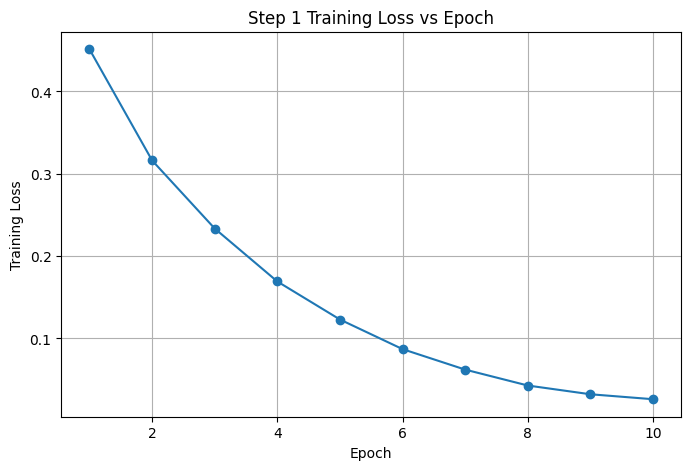

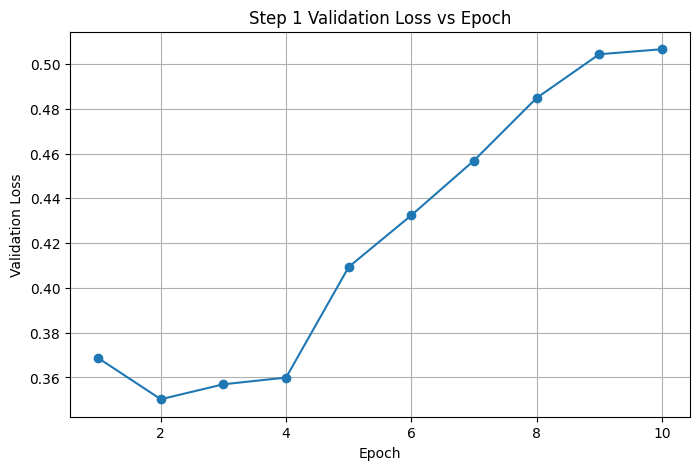

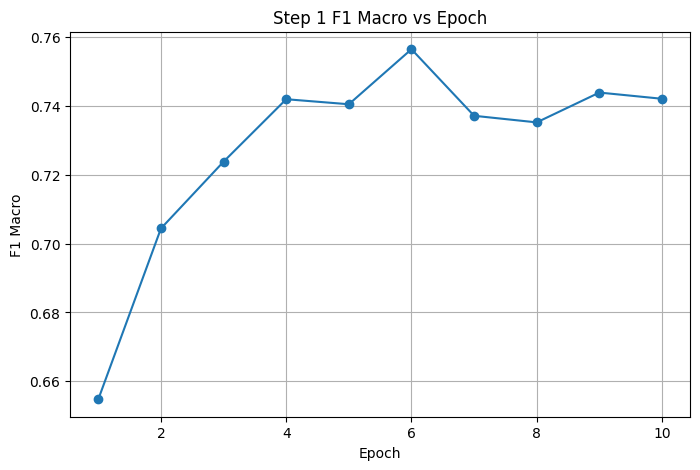

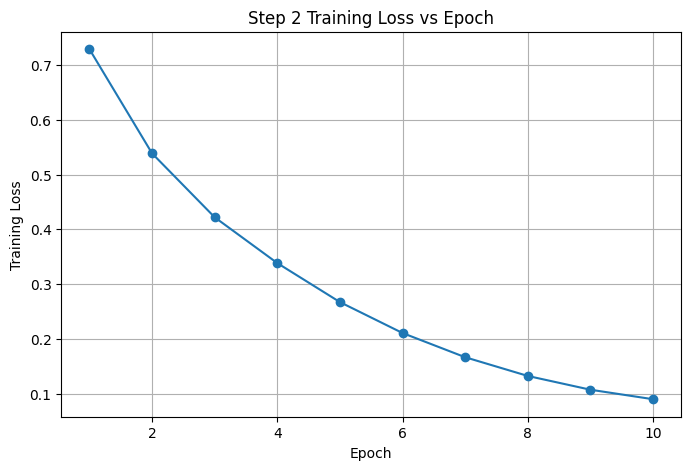

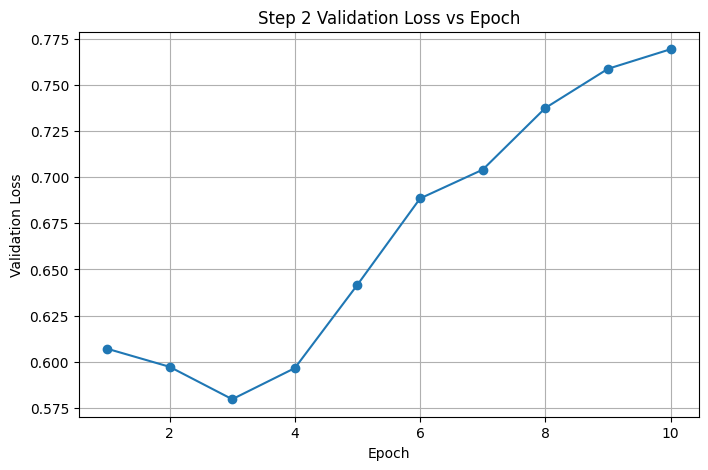

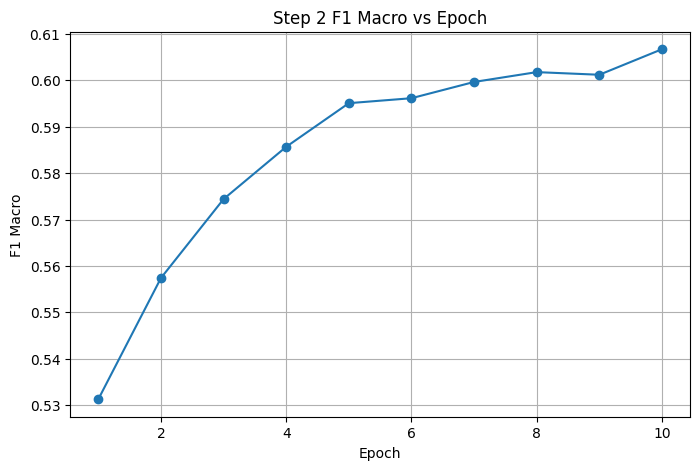

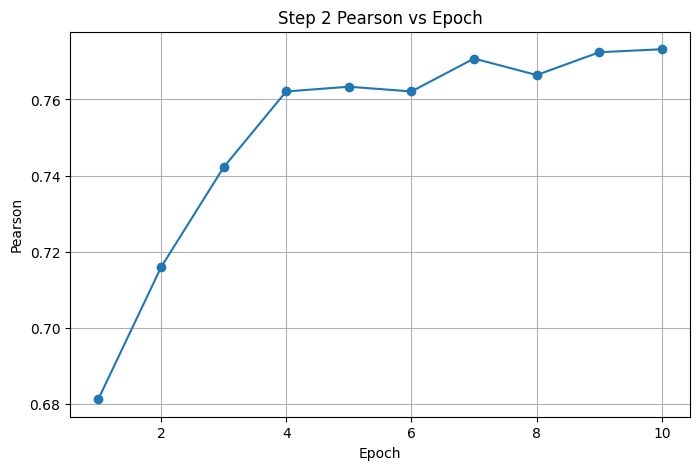

In [53]:
# =========================
# 28. PLOTS
# =========================
plt.figure(figsize=(8, 5))
plt.plot(step1_epoch_list, step1_train_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Step 1 Training Loss vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step1_epoch_list, step1_eval_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Step 1 Validation Loss vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step1_epoch_list, step1_f1_macro_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Step 1 F1 Macro vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step2_epoch_list, step2_train_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Step 2 Training Loss vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step2_epoch_list, step2_eval_loss_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Step 2 Validation Loss vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step2_epoch_list, step2_f1_macro_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("F1 Macro")
plt.title("Step 2 F1 Macro vs Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(step2_epoch_list, step2_pearson_list, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Pearson")
plt.title("Step 2 Pearson vs Epoch")
plt.grid(True)
plt.show()